In [14]:
import torch
import torchvision
from torchvision import datasets,transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torch.nn as nn
import numpy as np

In [3]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type=='cpu':
  print('using cpu')
else:
  print('using gpu|')

using gpu|


In [4]:
train_data=datasets.CIFAR10(train=True,transform=transforms.ToTensor(),root='./data',download=True)#totensor() converts PIL images[0,255] to tensor[0,1]   ->tonormalize((mean,),(std,)) is to normalize -> to do both use tocompose
train_loader=DataLoader(train_data,batch_size=64,shuffle=True, pin_memory=True)#Dataloader is an iterable i.e. has only __iter__() method
len(train_loader.dataset)

100%|██████████| 170M/170M [00:04<00:00, 39.3MB/s]


50000

In [15]:
# train_data[0]
# #tuple of (tensor(),int)
# train_iterator_object=iter(train_loader)
# batch=next(train_iterator_object)#here batch is a list of two tensors i.e. image and labels
# len(batch)

In [5]:
class encoder(nn.Module):#nn.Module ist the parent class for neural networks which helps to track model parameters,layers, etc
  def __init__(self,latent_dim,input_channel):
    super().__init__() #internally calls nn.Modules constructor ie nn.Module.__init__()
    self.latent_dim=latent_dim
    self.input_channel=input_channel
    self.encode=nn.Sequential(
        nn.Conv2d(input_channel,64,kernel_size=4,padding=1,stride=2),
        nn.ReLU(),
        nn.Conv2d(64,128,kernel_size=4,padding=1,stride=2),
        nn.ReLU(),
        nn.Conv2d(128,256,kernel_size=4,padding=1,stride=2),
        nn.ReLU(),
        nn.Flatten(),## Dim 0 = Batch, 1 = Channels, 2 = Height, 3 = Width (NCHW format in PyTorch)
        # nn.Flatten() flattens all dims except batch by default(i.e., dims 1 and onward) ie nn.Flatten(start_dim=1)
        nn.Linear(256*4*4,512)
        )
  def forward(self,x):
    encoding=self.encode(x)
    return encoding



In [6]:
class decoder(nn.Module):#nn.Module ist the parent class for neural networks which helps to track model parameters,layers, etc
  def __init__(self,latent_dim,input_channel):
    super().__init__() #internally calls nn.Modules constructor ie nn.Module.__init__()
    self.latent_dim=latent_dim
    self.input_channel=input_channel
    self.decode=nn.Sequential(
        nn.Linear(latent_dim,256*4*4),
        nn.ReLU(),
        nn.Unflatten(1,(256,4,4)),
        nn.ConvTranspose2d(256,128,kernel_size=4,padding=1,stride=2),
        nn.ReLU(),
        nn.ConvTranspose2d(128,64,kernel_size=4,padding=1,stride=2),
        nn.ReLU(),
        nn.ConvTranspose2d(64,input_channel,kernel_size=4,padding=1,stride=2),
        nn.Sigmoid()#pixel values are expected to be between (0,1)
        )
  def forward(self,x):
    reconst=self.decode(x)
    return reconst

In [7]:
class VAE(nn.Module):
  def __init__(self,latent_dim,input_channel):
    super().__init__()
    self.latent_dim=latent_dim
    self.input_channel=input_channel
    self.mu_layer=nn.Linear(512,latent_dim)
    self.logvar_layer=nn.Linear(512,latent_dim)
    self.encoder=encoder(latent_dim,input_channel)
    self.decoder=decoder(latent_dim,input_channel)
  def forward(self,x):
    encoding=self.encoder(x)
    mu=self.mu_layer(encoding)
    logvar=self.logvar_layer(encoding)
    sigma=torch.exp(0.5*logvar)
    z=torch.randn_like(sigma)*sigma + mu
    decoding=self.decoder(z)
    return decoding,mu,logvar


In [25]:

def ELBO_loss(mu,logvar,x,x_reconstructed,kl_weight=1,mse_weight=100):
  kl_loss=-1/2*torch.mean((logvar+1-mu**2-torch.exp(logvar)))
  mse_loss=((x-x_reconstructed)**2).mean()
  return kl_weight*kl_loss+mse_weight*mse_loss
# a,b,c=ELBO_loss(torch.randn(1,384),torch.randn(1,384),torch.randn(1,3,32,32),torch.randn(1,3,32,32))
# print(a.shape,b,c)

In [33]:

input_channels=3
latent_dim=128
model=VAE(latent_dim,input_channels).to(device)
optimizer=torch.optim.Adam(model.parameters(),lr=1e-3)

In [34]:
a=torch.randn(1,3,32,32)
a.shape[0]

1

In [35]:
num_epochs=100
outputs=[]
for epoch in range(num_epochs):
  running_loss=0
  for (img,_) in train_loader:
    img=img.to(device, non_blocking=True)
    x_recon,mu,logvar=model(img)
    optimizer.zero_grad()
    loss=ELBO_loss(mu,logvar,img,x_recon)
    loss.backward()
    optimizer.step()
    running_loss+=loss.item()*img.shape[0]#loss.item() gives loss per batch, so scale to per image and at end of one epoch running loss will be sum of individual loss of each 50000 images
  epoch_loss=running_loss/len(train_loader.dataset)#mean loss over all 50k image samples
  print(f"loss in epoch number {epoch}: {epoch_loss}")
  outputs.append((img.cpu(),x_recon.detach().cpu()))

loss in epoch number 0: 2.901616879119873
loss in epoch number 1: 2.0116798466873167
loss in epoch number 2: 1.8315629201889039
loss in epoch number 3: 1.7623565098571778
loss in epoch number 4: 1.713913610725403
loss in epoch number 5: 1.6817116979980469
loss in epoch number 6: 1.6619081742095947
loss in epoch number 7: 1.6437624100494386
loss in epoch number 8: 1.6252197045516967
loss in epoch number 9: 1.6105252480316161
loss in epoch number 10: 1.5987793608474732
loss in epoch number 11: 1.589056580657959
loss in epoch number 12: 1.5832713389587403
loss in epoch number 13: 1.575144882850647
loss in epoch number 14: 1.5682635544204713
loss in epoch number 15: 1.5592966555023193
loss in epoch number 16: 1.5545934902954102
loss in epoch number 17: 1.5451508902740478
loss in epoch number 18: 1.5392078326416017
loss in epoch number 19: 1.5328025482940675
loss in epoch number 20: 1.528191576538086
loss in epoch number 21: 1.5235303079986573
loss in epoch number 22: 1.5201079431533813
los

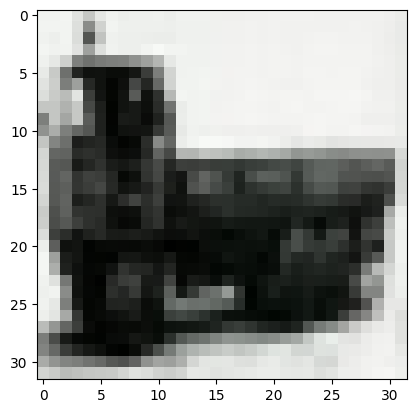

In [76]:
plt.imshow(img[3].cpu().numpy().transpose(1,2,0))

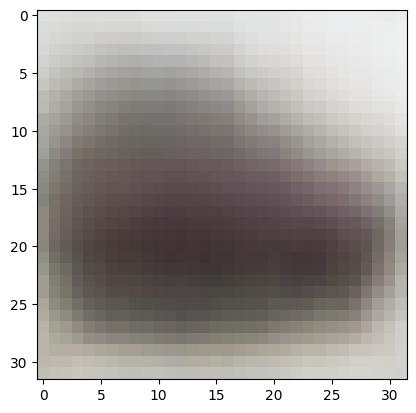

In [77]:
plt.imshow(x_recon[3].detach().cpu().numpy().transpose(1,2,0))

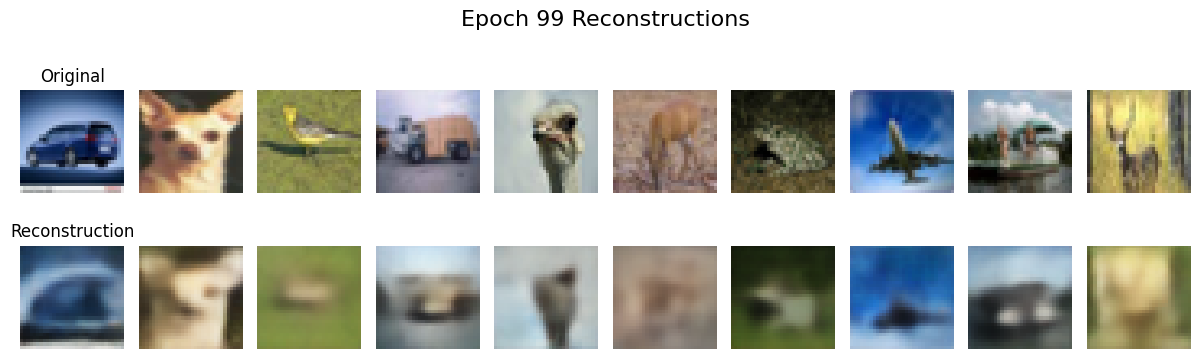

In [36]:
#plotting images shere
orig_imgs, recon_imgs = outputs[-1]
n = 10 #no of images
plt.figure(figsize=(12, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1) #original
    img = orig_imgs[i]
    # unnormalize from [-1,1] to [0,1] in case of tanh() as last layer
    #img = (img * 0.5) + 0.5 #inversefunction of normalization
    npimg = img.numpy().transpose((1, 2, 0))#matplotlib expects (h,w,c) and numpy arrays
    plt.imshow(np.clip(npimg, 0, 1)) #np.clip()<=(input_array,amin,amax) to avoid any round off error by denormalization
    ax.axis('off')
    if i == 0:
        ax.set_title('Original')

    # reconstructed
    ax = plt.subplot(2, n, n + i + 1)
    recon = recon_imgs[i]
    #recon = (recon * 0.5) + 0.5
    nprecon = recon.numpy().transpose((1, 2, 0))
    plt.imshow(np.clip(nprecon, 0, 1))
    ax.axis('off')
    if i == 0:
        ax.set_title('Reconstruction')

plt.suptitle(f'Epoch {epoch} Reconstructions', fontsize=16)
plt.tight_layout()
plt.show()

In [38]:
model.eval()
batch_size = 16
z = torch.randn(batch_size, latent_dim, device=device)
with torch.no_grad():
    generated = model.decoder(z)    # shape: [batch_size, 3, 32, 32]
imgs = generated.cpu().clamp(0,1)
from torchvision.utils import make_grid, save_image
grid = make_grid(imgs, nrow=4)
save_image(grid, 'generated.png')   # or plt.imshow(grid.permute(1,2,0))


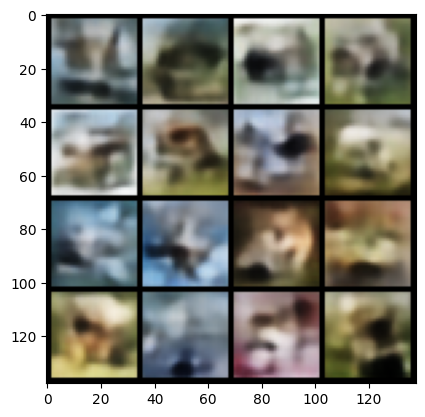

In [31]:
 plt.imshow(grid.permute(1,2,0))